In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.optimize import curve_fit

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
class Datalogger_Processing:
    def __init__(self, filepath):
      '''
      Class for processing datalogger files

      Arg:
        filepath: string of filepath to datalogger CSV
      '''
      self.fp = filepath

      self.fp_string = self.fp.split('/')[-1]

      self.df = pd.read_csv(self.fp)

    def process(self, plotting_title=None):
      '''
      Full pipeline: plots raw data vs Timer[S], detects timer resets, creates continuous Absolute Timer (S) column,
      and plots everything again vs Absolute Timer (S). Returns self.df so it can be chained into one line.

      Usage: datalogger_df = Datalogger_Processing(fp).process()
      '''
      self.subplots()                                                  # initial plot with raw Timer[S]
      self.separate_timer_resets(plotting_title=plotting_title)        # detects resets, builds Absolute Timer (S), re-plots vs it
      return self.df                                                   # return the fully-processed dataframe so caller can grab it directly

    def subplots(self, xaxis='Timer[S]', title=None):
      '''
      Method for subplots of datalogger data

      Args:
        Columns
      '''
      if title is None:
          title = self.fp_string

      fig1, axes = plt.subplots(1, 3, figsize=(20, 5))

      axes[0].plot(self.df[xaxis], self.df['Events CW1&2'], marker='o', markersize=0.7, color='blue', label="CW 1 & 2")
      axes[0].plot(self.df[xaxis], self.df['Events CW1&2&3'], marker='o', markersize=0.7, color='magenta', label="CW 1 & 2 & 3")
      axes[0].set_xlabel(xaxis)
      axes[0].set_ylabel('Events')
      axes[0].legend()
      axes[0].set_title('CosmicWatch Events over Time')

      axes[1].plot(self.df[xaxis], self.df['Pressure[Pa]'], marker='o', markersize=0.7, color='green', label="Pressure")
      axes[1].set_xlabel(xaxis)
      axes[1].set_ylabel('Pressure[Pa]')
      axes[1].legend()
      axes[1].set_title('Pressure over Time')

      axes[2].plot(self.df[xaxis], self.df['Temperature[C]'], marker='o', markersize=0.7, color='red', label="Temperature")
      axes[2].set_xlabel(xaxis)
      axes[2].set_ylabel('Temperature[C]')
      axes[2].legend()
      axes[2].set_title('Temperature over Time')

      plt.suptitle(title)
      plt.show()

    def separate_timer_resets(self, plotting_title=None):
      '''
      Detect any timer resets in the datalogger data, and creates separate DataFrames for each run. Then creates an Absolute Timer column to add to the dataframe, and plots the data as a function of the absolute timer.
      '''
      if plotting_title is None:
          plotting_title = self.fp_string

      self.df_sorted = self.df.copy().sort_index().reset_index(drop=True)                      # make sure rows are in original order + give clean 0-based index

      time_col = 'Timer[S]'                                                    # name of the column that holds the timer values

      reset_mask = self.df_sorted[time_col].diff() < -10                                # .diff() computes row-to-row differences; this creates a boolean mask that's True wherever the time decreased by more than 3 seconds (negative value indicates a reset/jump backward)

      new_segment_starts = [0] + (reset_mask[reset_mask].index).tolist()   # list of row numbers where each new segment begins: 0 + (index of each True + 1 to point to first row of next segment)
      print(f"Detected {len(new_segment_starts)-1} separate timer reset(s) at rows {new_segment_starts}")

      self.timerreset_segments = []                                                            # empty list that will store one DataFrame per continuous run

      for i in range(len(new_segment_starts)):                                 # loop over each detected starting point
        start = new_segment_starts[i]                                        # determine starting row index of current segment; store in "start"
        end = new_segment_starts[i+1] if i+1 < len(new_segment_starts) else None   # ending row = start of next segment, or None (means go to end of DataFrame)
        seg = self.df_sorted.iloc[start:end].copy()                                  # slice out this segment and make independent copy; iloc
        seg['Timer_rel'] = seg[time_col] - seg[time_col].iloc[0]             # add relative time column that starts at ~0 for this run
        self.timerreset_segments.append(seg)                                                 # store this segment in the list

      for i, seg in enumerate(self.timerreset_segments, 1):
        t_min = seg[time_col].min()
        t_max = seg[time_col].max()
        nrows = len(seg)
        print(f"  Run {i:2d}: {nrows:5d} rows, timer {t_min:6.0f} → {t_max:6.0f} s")

      self.create_absolute_timer()

      for i, start_idx in enumerate(new_segment_starts):
        print(f"\n--- Around start of Timer Reset {i+1} (row {start_idx}) ---")

        start = max(0, start_idx - 5)
        end   = start_idx + 6

        slice_df = self.df.iloc[start:end] # Changed from self.df_sorted to self.df

        print(slice_df[[time_col, 'Events CW1&2', 'Events CW1&2&3', 'Absolute Timer (S)']].to_string(index=True))

      self.subplots(xaxis='Absolute Timer (S)', title=plotting_title)


    def create_absolute_timer(self):
      '''
      Creates continuous Absolute Timer by chaining last value from before timer reset
      '''
      absolute_timers = []
      previous_end = 0.0

      for i, seg in enumerate(self.timerreset_segments):
        current_timers = seg['Timer[S]'].values

        if len(current_timers) == 0:
            continue

        absolute_this_segment = current_timers + previous_end

        absolute_timers.extend(absolute_this_segment)

        previous_end = absolute_this_segment[-1]

      self.df['Absolute Timer (S)'] = absolute_timers

## 0 Degrees Datalogger

In [6]:
datalogger_csv_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_DATALOGGER.csv' # @param {type:"string"}
top_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_TOP.txt' # @param {type:"string"}
mid_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_MID.txt' # @param {type:"string"}
bot_scint_fp = '/content/drive/MyDrive/2026_ Jan 15 (Ground Testing -- 45 deg)/2HR_Ground_Test_0_Deg_BOT.txt' # @param {type:"string"}

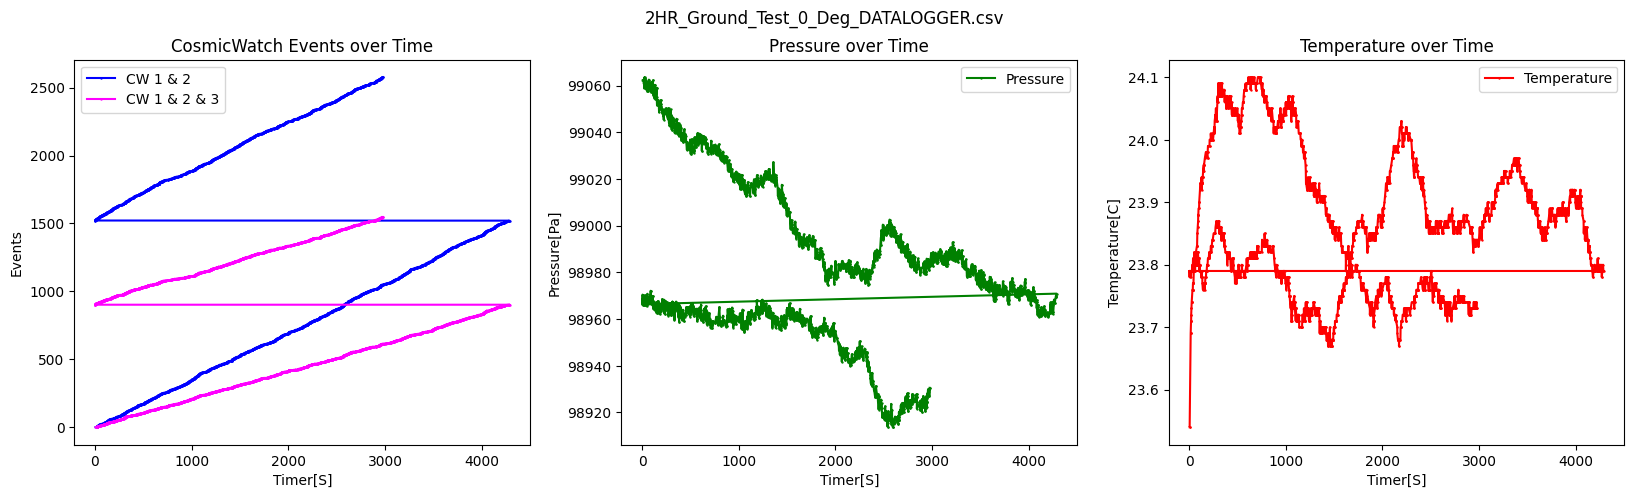

Detected 1 separate timer reset(s) at rows [0, 2423]
  Run  1:  2423 rows, timer      6 →   4289 s
  Run  2:  1702 rows, timer      2 →   2975 s

--- Around start of Timer Reset 1 (row 0) ---
    Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
0   5.849609             1               0            5.849609
1   5.855468             1               1            5.855468
2  16.342773             2               1           16.342773
3  16.415039             3               1           16.415039
4  16.420898             3               2           16.420898
5  19.281250             4               2           19.281250

--- Around start of Timer Reset 2 (row 2423) ---
         Timer[S]  Events CW1&2  Events CW1&2&3  Absolute Timer (S)
2418  4269.168945          1518             901         4269.168945
2419  4281.617187          1519             901         4281.617187
2420  4286.391601          1520             901         4286.391601
2421  4286.411132          1520             9

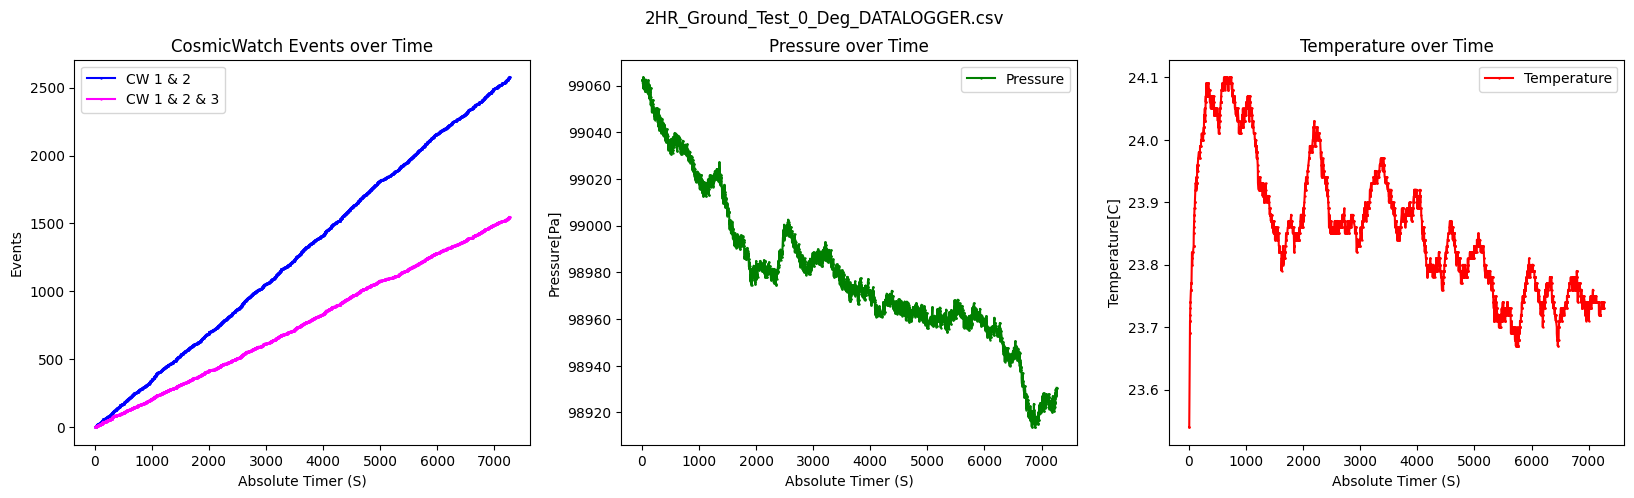

In [7]:
datalogger_df = Datalogger_Processing(datalogger_csv_fp).process()

In [8]:
datalogger_df

,Events CW1&2,Events CW1&2&3,Temperature[C],Pressure[Pa],Date[MM/DD/YYYY],RTC[H:M:S EST],Timer[S],Latitude,Longitude,Altitude[m],...,Accel y,Accel z,Gyro x,Gyro y,Gyro z,Mag x,Mag y,Mag z,Battery[],Absolute Timer (S)
0,1,0,23.54,99062.22,1/1/1970,0:0:10.843,5.849609,0.0,0.0,0.0,...,9.02334,-1.12223,1.97187,-0.41050,-0.04520,-68.40105,-25.02192,-85.39900,95,5.849609
1,1,1,23.54,99062.22,1/1/1970,0:0:10.843,5.855468,0.0,0.0,0.0,...,9.02334,-1.12223,1.97187,-0.41050,-0.04520,-68.40105,-25.02192,-85.39900,95,5.855468
2,2,1,23.69,99062.56,1/15/2026,0:27:08.348,16.342773,0.0,0.0,0.0,...,9.78784,0.48814,0.02443,-0.04154,-0.00489,-81.84741,-46.21456,-100.38000,94,16.342773
3,3,1,23.69,99062.15,1/15/2026,0:27:08.421,16.415039,0.0,0.0,0.0,...,9.79143,0.48933,0.02321,-0.04032,-0.00489,-81.08740,-45.89301,-98.90382,94,16.415039
4,3,2,23.69,99062.15,1/15/2026,0:27:08.421,16.420898,0.0,0.0,0.0,...,9.79143,0.48933,0.02321,-0.04032,-0.00489,-81.08740,-45.89301,-98.90382,94,16.420898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4120,2575,1546,23.73,98929.57,1/15/2026,2:28:10.386,2968.011219,0.0,0.0,0.0,...,9.79502,0.46540,0.02321,-0.03910,-0.00489,-79.74277,-48.49459,-107.48318,96,7256.871570
4121,2576,1546,23.74,98927.02,1/15/2026,2:28:14.683,2972.255360,0.0,0.0,0.0,...,9.78306,0.47019,0.02321,-0.04032,-0.00489,-78.99737,-48.05612,-107.99474,96,7261.115711
4122,2576,1547,23.74,98927.02,1/15/2026,2:28:14.683,2972.271961,0.0,0.0,0.0,...,9.78306,0.47019,0.02321,-0.04032,-0.00489,-78.99737,-48.05612,-107.99474,96,7261.132312
4123,2577,1547,23.73,98930.53,1/15/2026,2:28:17.522,2975.080555,0.0,0.0,0.0,...,9.79143,0.46660,0.02321,-0.04032,-0.00489,-79.20198,-48.91845,-108.30167,96,7263.940906


In [9]:
print([repr(c) for c in datalogger_df.columns])

["'Events CW1&2'", "'Events CW1&2&3'", "'Temperature[C]'", "'Pressure[Pa]'", "'Date[MM/DD/YYYY]'", "'RTC[H:M:S EST]'", "'Timer[S]'", "'Latitude'", "'Longitude'", "'Altitude[m]'", "'Sats'", "'Accel x'", "'Accel y'", "'Accel z'", "'Gyro x'", "'Gyro y'", "'Gyro z'", "'Mag x'", "'Mag y'", "'Mag z'", "'Battery[]'", "'Absolute Timer (S)'"]


The datalogger file contains coincidence events across CosmicWatches 1&2, and 1, 2 & 3 along with the time stamps for all coincidence events. However, the scintillator files for each individual CosmicWatch contain data with a timestamp of any time that individual CosmicWatch scintillated. We are interested in the signal in mV on each individual scintillator at the point in time where there was three scintillator coincidence. In other words, we want to see the SiPM signal, in mV, for each scintillator (located in the files for each scintillator) ONLY at the time stamps where there was three-scintillator coincidence, indicating a pure muon sample.

Aligned/combined dataframe headers Index(['Events CW1&2', 'Events CW1&2&3', 'Temperature[C]', 'Pressure[Pa]',
       'Date[MM/DD/YYYY]', 'RTC[H:M:S EST]', 'Timer[S]', 'Latitude',
       'Longitude', 'Altitude[m]', 'Sats', 'Accel x', 'Accel y', 'Accel z',
       'Gyro x', 'Gyro y', 'Gyro z', 'Mag x', 'Mag y', 'Mag z', 'Battery[]',
       'Absolute Timer (S)', 'Time_scint1[s]', 'SiPM_scint1[mV]',
       'ADC_scint1[0-4095]', 'Coincident_scint1[bool]', 'Deadtime_scint1[s]',
       'livetime_scint1[s]', 'Time_scint2[s]', 'SiPM_scint2[mV]',
       'ADC_scint2[0-4095]', 'Coincident_scint2[bool]', 'Deadtime_scint2[s]',
       'livetime_scint2[s]', 'Time_scint3[s]', 'SiPM_scint3[mV]',
       'ADC_scint3[0-4095]', 'Coincident_scint3[bool]', 'Deadtime_scint3[s]',
       'livetime_scint3[s]'],
      dtype='object')

Match offset stats (seconds):
count    4125.0000
mean        0.2618
std         0.2634
min         0.0000
25%         0.0711
50%         0.1793
75%         0.3738
max         2.0641
N

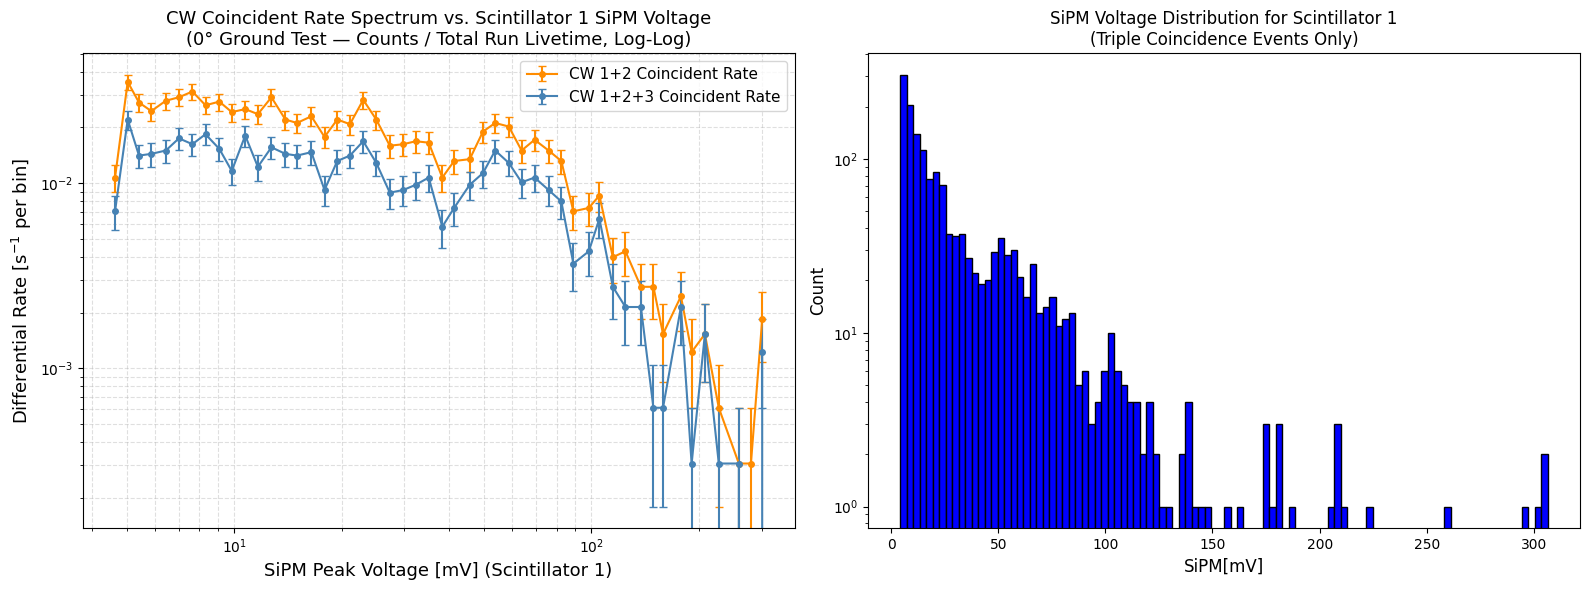

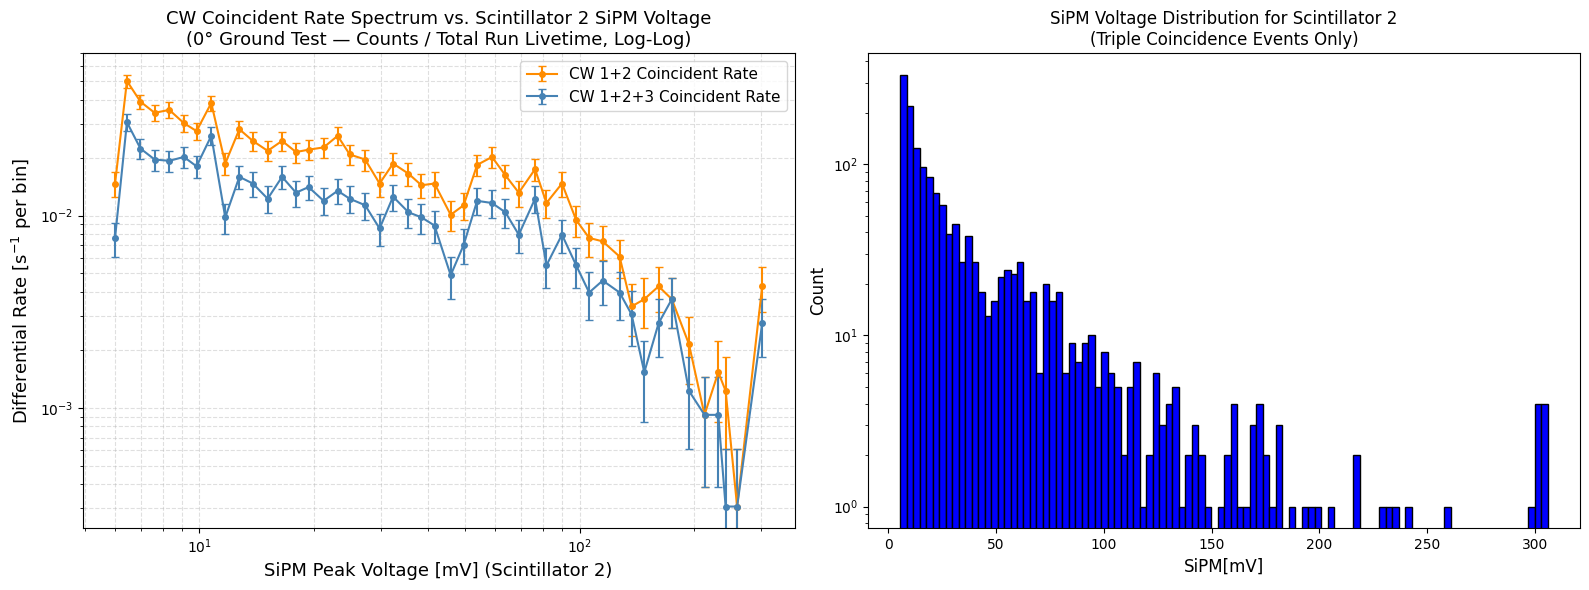

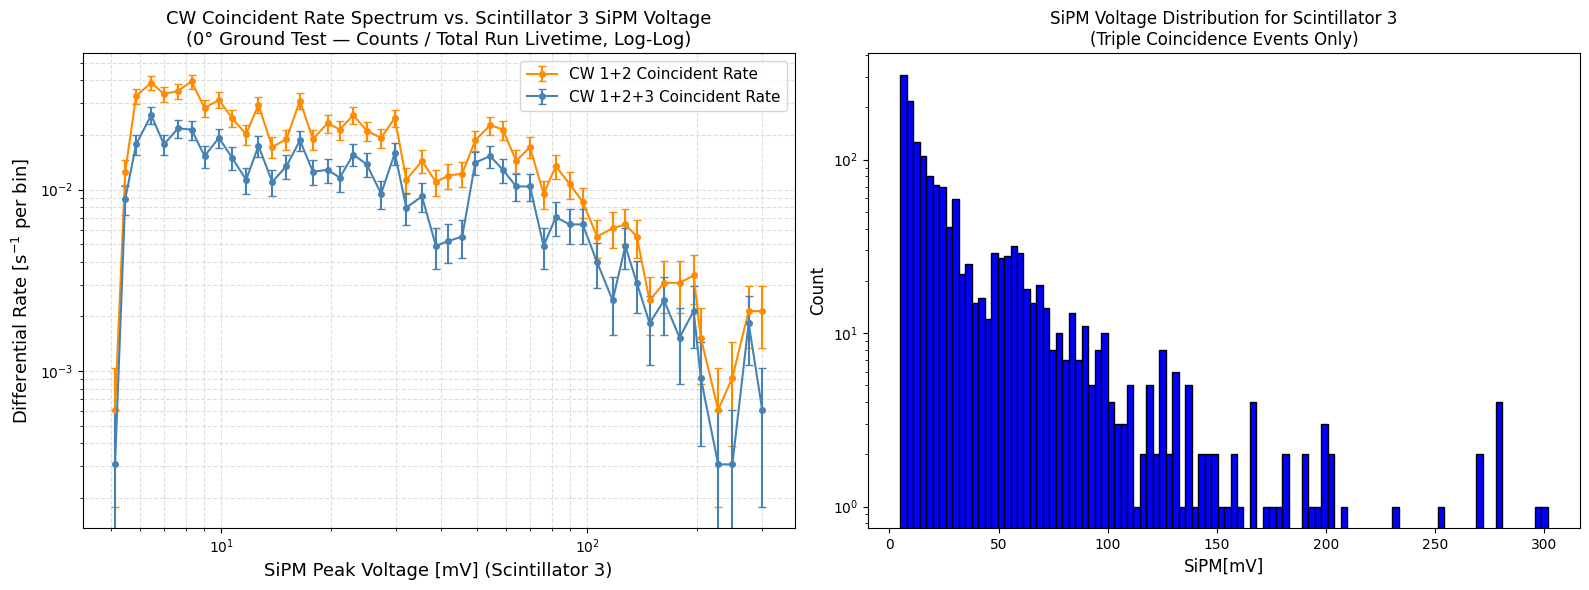


Scintillator 1 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 4.40 mV, Max: 306.40 mV, Mean: 30.58 mV

Scintillator 2 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 5.70 mV, Max: 305.80 mV, Mean: 34.50 mV

Scintillator 3 — SiPM_mV_CW123 stats:
  Non-null count: 1548
  Min: 5.10 mV, Max: 301.50 mV, Mean: 33.03 mV


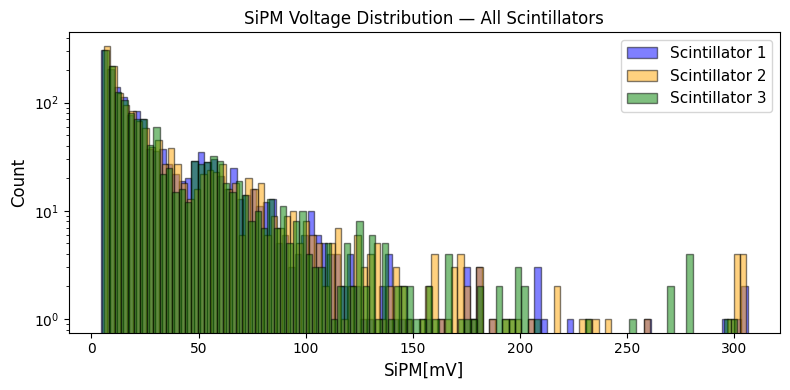

Moyal fit — MPV: 55.12 mV, eta: 12.71 mV, A: 0.1558
Moyal fit — MPV: 57.06 mV, eta: 14.41 mV, A: 0.0318
Moyal fit — MPV: 56.42 mV, eta: 12.63 mV, A: 0.0213


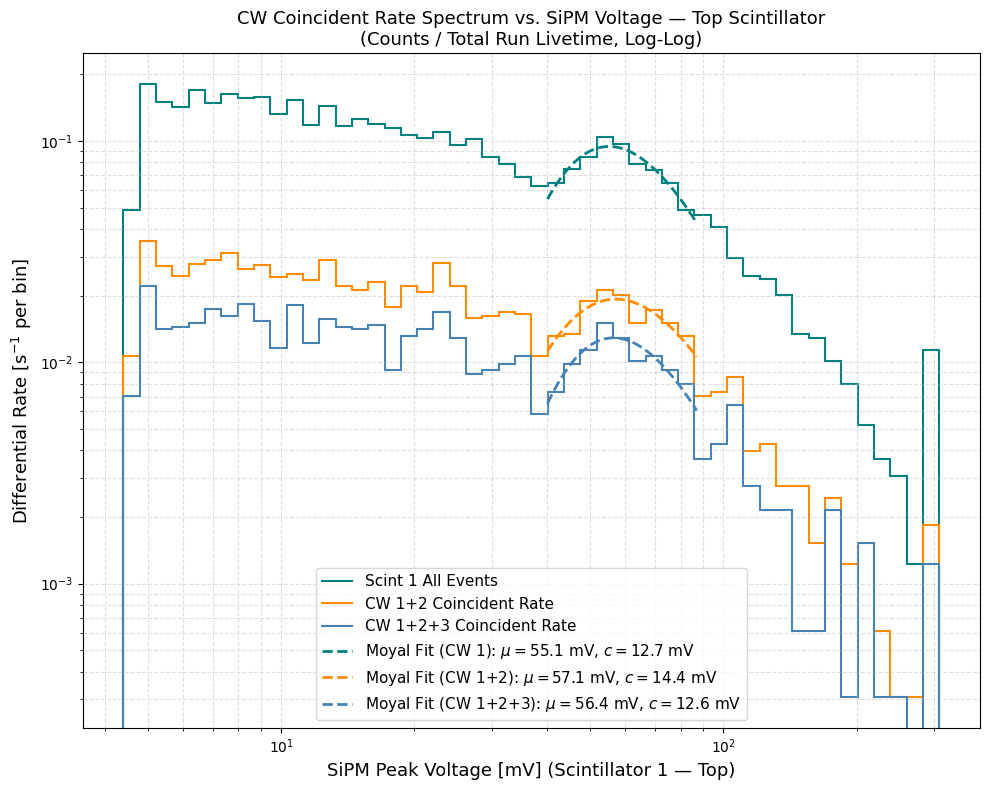

In [24]:
class Scintillator_Processing:
    def __init__(self, filepaths):
      '''
      Class for processing scintillator files

      Arg:
        filepaths: list of filepath strings for each scintillator TXT
      '''
      self.fps = filepaths

      columns = ['Event','Time[s]','Coincident[bool]','ADC[0-4095]','SiPM[mV]','Deadtime[s]','Temp[C]','Pressure[Pa]']

      for i, fp in enumerate(filepaths, start=1):
            df = pd.read_csv(fp, sep='\t', comment='#', header=None, skiprows=3, names=columns, engine='python')
            setattr(self, f'scint_{i}', df)

    def apply_deadtime_correction(self, i):
      """
      Computes deadtime-corrected per-event livetime for scintillator i,
      using the same approach as getCosmicWatch() in the reference script.

      For each event row, livetime = (time elapsed since last event) - (deadtime accumulated since last event)
      This is then attached to the scintillator DataFrame as a column before merging.

      Args:
          i: scintillator index (1-based)

      Returns:
          pd.Series of deadtime-corrected livetime values, aligned to scint_i's index
      """
      scint_df = getattr(self, f'scint_{i}')
      time  = scint_df['Time[s]'].values
      deadt = scint_df['Deadtime[s]'].values

      # delta deadtime per event (same np.diff + prepend pattern as colleague's script)
      event_deadt_s    = np.diff(np.append([0], deadt))
      event_livetime_s = np.diff(np.append([0], time)) - event_deadt_s

      # clip negatives — can occur at file boundaries or timer resets
      event_livetime_s = event_livetime_s.clip(min=0)

      return pd.Series(event_livetime_s, index=scint_df.index, name=f'livetime_scint{i}[s]')

    def align_with_datalogger(self, datalogger_df_raw, NUM_BINS=50):
      '''
      Create a new dataframe that has all the rows from datalogger plus adds the corresponding columns from the given scintillator where they have
      close enough timestamp matches, with NaN in fields where there was not a close enough time match.


      Result:
          self.aligned_df : dataframe with only data from the specified scintillator at the points where all three were in coincidence
          self.binned_and_aligned_df_i: dataframe with column headers "mV_bin", "mean_mV", "count_12", "count_123",
              "rate_12", "rate_123", "n_events", "err_12", "err_123" — i.e. the SiPM bin, mean SiPM value,
              raw event counts per bin, differential rate spectrum per bin (counts / total run livetime, units s^-1),
              number of triple-coincidence events binned, and Poisson errors on the rates.
      '''
      dl_df = datalogger_df_raw.sort_values('Absolute Timer (S)').reset_index(drop=True)  # sorting the raw datalogger DataFrame by 'Absolute Timer (S)' and dropping/rebuilding the index so rows are in true chronological order; required because pd.merge_asof below demands its left key be sorted, and the per-segment 'Timer[S]' column resets to 0 mid-run which would otherwise scramble row order
      aligned = dl_df.copy()  # making an independent copy of the sorted datalogger frame to serve as the running "base" table that each scintillator's columns will be progressively merged into; copying (rather than aliasing) so subsequent column additions don't mutate the user's original input

      # looping through each of the provided scintillator files
      for i in range(1, len(self.fps) + 1):  # iterating over each scintillator file the class was initialised with, so we can look up the matching scint_1, scint_2, ... attributes set in __init__ and merge each one into 'aligned' in turn
          scint_df = getattr(self, f'scint_{i}')[['Time[s]','SiPM[mV]','ADC[0-4095]','Coincident[bool]','Deadtime[s]']].copy()  # slicing the i-th scintillator DataFrame attribute by its dynamic name, slicing down to only the five columns we need downstream (timestamp, SiPM pulse height, raw ADC code, coincidence flag, cumulative deadtime), and copying so we can rename/mutate it without touching the original attribute on self
          livetime_series = self.apply_deadtime_correction(i)  # calling the helper method to compute a per-event deadtime-corrected livetime Series for scintillator i (each entry = elapsed wall-time since previous event minus deadtime accumulated since previous event); needed so we can later sum these to a single scalar total run livetime that serves as the denominator of the differential rate spectrum
          scint_df[f'livetime_scint{i}[s]'] = livetime_series.values  # attaching the per-event livetime values as a new column on the slimmed scintillator DataFrame, using .values to drop the index and align purely positionally; doing this BEFORE the merge so the livetime column travels with each scintillator row into the merged 'aligned' frame
          # renaming columns to combine into one large dataframe with datalogger
          scint_df = scint_df.rename(columns={  # renaming every column to be suffixed with the scintillator index so that when multiple scintillators' frames are merged into a single 'aligned' DataFrame, columns don't collide (e.g. SiPM_scint1[mV] vs SiPM_scint2[mV] coexist instead of overwriting each other)
              'Time[s]':        f'Time_scint{i}[s]',
              'SiPM[mV]':       f'SiPM_scint{i}[mV]',
              'ADC[0-4095]':    f'ADC_scint{i}[0-4095]',
              'Coincident[bool]': f'Coincident_scint{i}[bool]',
              'Deadtime[s]':        f'Deadtime_scint{i}[s]',
              f'livetime_scint{i}[s]': f'livetime_scint{i}[s]',
          }).sort_values(f'Time_scint{i}[s]').reset_index(drop=True)  # chaining a sort by the newly-renamed scint timestamp column (required by merge_asof's right key being sorted) and then resetting the index so positional alignment is clean post-sort

          # pd.merge_asof(...) merges rows based on the closest matching value in a sorted key column (usually time); "For each row in dl_df, find the closest time in scint_df and join them."
          # creating new dataframe that has all the rows from the raw datalogger file sorted by absolute timer, but adds the corresponding columns from each scintillator txt file (scint_df in each iteration over the scints) where it has a close enough time match within the scintillator's time value in its txt file column to the Absolute Timer values of the datalogger
          # puts NaN in fields where there was not a close enough time match
          aligned = pd.merge_asof(  # performing a nearest-neighbour time-based join: for every row in 'aligned' (which starts as the datalogger and accumulates scintillator columns each loop iteration), find the row in scint_df whose timestamp is closest to the datalogger row's 'Absolute Timer (S)' and append its columns; rows with no scint match within tolerance receive NaN in the new columns
              aligned, scint_df,                  # left = the running aligned frame (datalogger + any previously-merged scintillators), right = the current scintillator's frame; merge_asof broadcasts scint columns onto every datalogger row via nearest-time match
              left_on='Absolute Timer (S)',       # the timestamp column on the left (datalogger) side to match against; we use cumulative 'Absolute Timer (S)' rather than per-segment 'Timer[S]' because the latter resets to 0 mid-run and would produce wrong matches across reset boundaries
              right_on=f'Time_scint{i}[s]',       # the timestamp column on the right (scintillator) side to match against, using the renamed per-scint name so the merge knows which column carries this scint's clock
              direction='nearest',                # tells merge_asof to pick the closest scint timestamp in either direction (before or after the datalogger time), rather than only-backward or only-forward; appropriate here because the two clocks are independent and either can lead at any given row
              tolerance=5.0                       # caps the maximum allowed time gap between a datalogger row and its matched scint row at 5.0 seconds — rows further apart than this get NaN scint columns rather than a spurious far-away match (datalogger samples once per second, so 5 s is generous slack but well below typical event spacing)
          )

      # at the end of the for loop, aligned is a dataframe that contains the datalogger original data, plus selected columns from each of the scintillator individual files

      print(f"Aligned/combined dataframe headers {aligned.columns}")  # diagnostic print of the final list of column names after every scintillator has been merged in, so the user can sanity-check that all expected per-scint columns made it into 'aligned' before any downstream computation is done

      aligned['dt_match[s]'] = (aligned['Absolute Timer (S)'] - aligned['Time_scint1[s]']).abs()  # adding a new column equal to the absolute time difference between each datalogger row and its matched scintillator-1 row in seconds; used purely as a diagnostic for how good the time alignment is — small values mean tight matches, values pushing the 5 s tolerance mean the closest scint event was nearly out of range
      print(f"\nMatch offset stats (seconds):")  # header line for the diagnostic statistics print on the next line
      print(aligned['dt_match[s]'].describe().round(4))  # printing summary stats (count, mean, std, min, quartiles, max) of the match-offset column rounded to 4 decimal places, so the user can see at a glance whether matches are typically sub-second or pushing the tolerance limit

      # ── Per-row event counts and total run livetime ──────────────────────
      # delta of the running CW counters → per-row event counts
      # (clip negatives that can occur at counter resets/restarts)
      aligned['delta_CW12']  = aligned['Events CW1&2'].diff().clip(lower=0).fillna(0)  # converting the cumulative CW1+2 counter into per-row event counts: .diff() takes consecutive first-differences, .clip(lower=0) zeroes out any negatives produced when the counter resets back to a smaller number, and .fillna(0) handles the very first row's NaN (no previous row to diff against);
                                                                                          # the result is the per-row count of NEW CW1+2 coincidence events that occurred between this datalogger sample and the last
      aligned['delta_CW123'] = aligned['Events CW1&2&3'].diff().clip(lower=0).fillna(0)  # identical operation but on the CW1+2+3 (triple coincidence) cumulative counter, yielding per-row triple-coincidence event counts that will serve as the numerator weights when building the triple-coincidence rate spectrum

      # Total run livetime: sum of deadtime-corrected per-event livetimes from the master scintillator (scint 1).
      # This is a single scalar — the denominator for every bin in the differential rate spectrum below.
      # We deliberately do NOT bin time into 60s windows or take any per-window rate average; that approach
      # estimates "average instantaneous rate during periods when events of voltage v fired" rather than the
      # count-rate spectrum dN/dt per pulse-height bin that we actually want.
      total_livetime_s = aligned['livetime_scint1[s]'].clip(lower=0).fillna(0).sum()  # computing a single scalar total deadtime-corrected livetime for the run by clipping any negative per-event livetimes to 0 (defensive against file-boundary glitches), filling merge-induced NaNs with 0, and summing across all rows of scintillator-1's livetime column; this scalar is the denominator for every bin in the differential rate spectrum (giving rates in s^-1) — scint 1 is used specifically because both CW1+2 and CW1+2+3 are keyed off scint 1 firing
      self.total_livetime_s = total_livetime_s  # stashing the scalar on the instance so other methods (and the user post-hoc) can access it without recomputing
      print(f"\nTotal run livetime (deadtime-corrected, scint 1): {total_livetime_s:.2f} s")  # diagnostic print of the total livetime to two decimals so the user can verify it's roughly the wall-clock duration of the run minus expected deadtime
      if total_livetime_s > 0:  # guarding against divide-by-zero in the rate prints below in the degenerate case of an empty/zero-livetime run (e.g. if the file was truncated or the merge produced no scint-1 matches)
          print(f"Run-averaged CW1+2 rate:   {aligned['delta_CW12'].sum()  / total_livetime_s:.3f} s^-1")  # printing the overall integrated CW1+2 rate (sum of per-row counts ÷ total livetime) to three decimals as a sanity check that the rate sits in the expected ~Hz ballpark for cosmic muons at this geometry
          print(f"Run-averaged CW1+2+3 rate: {aligned['delta_CW123'].sum() / total_livetime_s:.3f} s^-1")  # same calculation but for triple coincidence; expected to be substantially smaller than CW1+2 since requiring all three scintillators to fire is a much tighter selection
      # ──────────────────────────────────────────────────────────────────────


      # creating a new column for each scintillator in the master dataframe that gives that SiPM's voltage ONLY at triple-coincidence events (delta_CW123 > 0) and is NaN everywhere else
      for i in range(1, len(self.fps) + 1):  # looping over scintillators a second time, this time to build a per-scint column that holds each scint's SiPM voltage but masked down to triple-coincidence rows only
        aligned[f'SiPM_mV_CW123_scint{i}'] = aligned[f'SiPM_scint{i}[mV]'].where(aligned['delta_CW123'] > 0)  # creating a new column that equals scint i's SiPM voltage on rows where a triple-coincidence event occurred (delta_CW123 > 0) and is NaN everywhere else; .where() keeps values where the condition is True and inserts NaN where it is False — gives a clean voltage series for histogramming/binning the triple-coincidence subset without having to filter the full DataFrame each time


      # pairwise SiPM voltage differences between scintillators ONLY at triple-coincidence events (NaN on non-triple-coincidence rows propagates automatically)
      aligned['SiPM_diff_scint1_minus_scint2'] = aligned['SiPM_mV_CW123_scint1'] - aligned['SiPM_mV_CW123_scint2']  # adding a column with the per-event voltage difference between scint 1 and scint 2 on triple-coincidence rows only (NaN propagates automatically from either operand on non-triple rows, keeping them masked); useful for verifying the three scintillators report consistent pulse heights for the same passing particle
      aligned['SiPM_diff_scint2_minus_scint3'] = aligned['SiPM_mV_CW123_scint2'] - aligned['SiPM_mV_CW123_scint3']  # same idea between scint 2 and scint 3, completing the chain of pairwise comparisons (the scint1 - scint3 difference is implicitly the sum of these two and so isn't computed separately)

      sipm_cols = ['SiPM_mV_CW123_scint1', 'SiPM_mV_CW123_scint2', 'SiPM_mV_CW123_scint3']  # building a Python list of the three masked SiPM voltage column names so the next two lines can compute row-wise statistics across them in a single vectorised call instead of writing out each column explicitly
      aligned['SiPM_scints_avg'] = aligned[sipm_cols].mean(axis=1, skipna=False)  # adding a column with the row-wise mean of the three scintillator SiPM voltages ONLY ON TRIPLE-COINCIDENCE EVENT rows; axis=1 means "mean across columns within each row", and skipna=False makes the mean NaN if ANY of the three is NaN — guaranteeing a value only appears on rows where all three scints actually fired (true triples)
      aligned['SiPM_scints_std'] = aligned[sipm_cols].std(axis=1, ddof=1, skipna=False)  # adding a column with the row-wise sample standard deviation (ddof=1 → divide by N-1 = 2) of the three scint SiPM voltages on triple-coincidence rows; quantifies how consistent the three pulse heights are per event, again with skipna=False so the value only exists for true triples

      self.aligned_df = aligned.copy()  # storing a copy of the fully-built aligned DataFrame as an instance attribute so plotting methods and the end user can access the merged/derived data after this method returns; copying (not aliasing) so external mutations of self.aligned_df don't corrupt the local 'aligned' that we still use below


      s1 = self.scint_1.copy()  # making an independent copy of the master (top) scintillator's full unfiltered DataFrame; we'll use this to build an "all events on scint 1" rate spectrum dataset that includes events not matched to any datalogger row, providing an unbiased pulse-height baseline for comparison against the coincidence-cut spectra
      s1['livetime[s]'] = self.apply_deadtime_correction(1).values  # attaching per-event deadtime-corrected livetimes to the scint-1 copy via .values for positional (index-free) assignment; not strictly required by what follows in this method but kept for symmetry/parity with the merged path

      datasets = []  # initialising the list of dataset dicts that will be passed to compute_rate_spectra; each dict describes one rate spectrum to compute on a shared set of bin edges
      # adding just scint 1 all events, unfiltered for coincidence, as a baseline
      datasets.append({'label'    : 'scint1_all_events',                   # appending the first dataset entry: a dict labelling this as the all-events-on-scint-1 baseline (no coincidence cut applied)
                      'sipm_mV'  : s1['SiPM[mV]'].values,                  # the SiPM voltage array for every event in scint 1 as a NumPy array (.values strips the pandas index, which compute_rate_spectra doesn't need)
                      'count_12' : None,                                   # no coincidence-count info applies to "all events"; passing None tells compute_rate_spectra to substitute zeros so the count_12/rate_12 columns of this dataset come out as 0 (only n_events is meaningful for this dataset)
                      'count_123': None,})                                 # same — no triple-coincidence info applies to the all-events dataset

      # adding each individual scintillator datasrt, to the dictionary
      for i in range(1, len(self.fps) + 1):  # looping over each scintillator to add a per-scint dataset to the list, so compute_rate_spectra builds one rate-spectrum DataFrame for each
          datasets.append({'label'    : f'scint{i}',                       # human-readable label that compute_rate_spectra will use as the key in its returned dict (e.g. 'scint1', 'scint2', 'scint3')
                          'sipm_mV'  : aligned[f'SiPM_scint{i}[mV]'].values,   # the SiPM voltage array from the merged 'aligned' DataFrame for scintillator i, including NaNs for unmatched datalogger rows (compute_rate_spectra will drop those before binning)
                          'count_12' : aligned['delta_CW12'].values,       # the per-row CW1+2 event-count series (computed above) used as numerator weights when binning to build the CW1+2 rate spectrum
                          'count_123': aligned['delta_CW123'].values,})    # the per-row CW1+2+3 event-count series, used analogously to build the triple-coincidence rate spectrum

      # now passing all datasets to the compute_rate_spectra method
      self.bin_edges, spectra = self.compute_rate_spectra(datasets, total_livetime_s)  # delegating the actual binning + rate-computation work to compute_rate_spectra and unpacking its two return values: a shared 1D array of log-spaced voltage bin edges (so all datasets can be plotted on identical x-axes) and a dict mapping each dataset's label to its mV-binned DataFrame
      print(spectra)                                                                                  # for the spectra dictionary, the scint_1_all_events will show
      self.spectra = spectra  # spectra object created by the rate spectra class above — stashing the full spectra dict on the instance so downstream methods (plot_all_scintillators, etc.) and the user can access every dataset's binned spectrum by label
      for i in range(1, len(self.fps) + 1):  # looping once more over scintillator indices to expose each per-scint binned spectrum as its own dedicated attribute (binned_and_aligned_df_1, _2, _3) for convenience, so callers can grab one specific spectrum without indexing into self.spectra
          setattr(self, f'binned_and_aligned_df_{i}', spectra[f'scint{i}'])  # dynamically setting the attribute on self by name (binned_and_aligned_df_i), pulling the matching binned DataFrame out of the spectra dict using the f'scint{i}' label that compute_rate_spectra used as that entry's dict key

    def compute_rate_spectra(self, datasets, total_livetime, NUM_BINS=50):
      """
      Computes differential rate spectra for multiple datasets on identical log-spaced bin edges.

      Args:
          datasets:        list of dicts, each with keys:
                              'label'      : string identifier
                              'sipm_mV'    : array-like of SiPM voltages [mV]
                              'count_12'   : array-like of per-row CW1+2 counts (or None)
                              'count_123'  : array-like of per-row CW1+2+3 counts (or None)
          total_livetime:  scalar deadtime-corrected run livetime [s]
          NUM_BINS:        number of log-spaced bins (default 50)

      Returns:
          bin_edges:  1D array of shape (NUM_BINS+1,) containing the log-spaced voltage bin
                      edges [mV] shared across all datasets. Pass directly to ax.stairs().

          results:    dict mapping each dataset label (e.g. 'scint1', 'scint1_all_events') to
                      a binned DataFrame of shape (NUM_BINS, 8) with one row per voltage bin, where each row looks like:

                          mV_bin    : pd.Interval — the voltage bin this row represents,
                                      e.g. (4.2, 6.1] mV
                          mean_mV   : mean SiPM voltage [mV] of all events that fell in this bin;
                                      NaN if the bin is empty
                          count_12  : total number of CW1+2 coincidence events whose scintillator
                                      voltage fell in this bin; 0 for scint1_all_events (no coincidence data)
                          count_123 : same as count_12 but for CW1+2+3 triple-coincidence events
                          n_events  : total number of raw scintillator events (any trigger) in this bin
                          rate_12   : count_12 / total_livetime [s^-1] — differential coincidence rate
                                      for this bin
                          rate_123  : count_123 / total_livetime [s^-1] — same for triple coincidence
                          err_12    : sqrt(count_12) / total_livetime [s^-1] — Poisson uncertainty on rate_12
                          err_123   : sqrt(count_123) / total_livetime [s^-1] — Poisson uncertainty on rate_123
      """
      # ── Compute global voltage range across all datasets ──────────────────
      all_sipm = np.concatenate([np.asarray(d['sipm_mV']).ravel() for d in datasets])  # building a single flat 1D NumPy array containing every SiPM voltage value across every dataset: the list comprehension iterates each dataset dict d, pulls out its 'sipm_mV' array-like, np.asarray() converts to numpy array, .ravel() flattens to 1D in case any input came in 2D, and np.concatenate() glues the per-dataset arrays end-to-end into one big array; needed so the bin edges below are determined by the union of all datasets' voltage ranges and every dataset shares identical bin edges (so spectra are directly comparable / overlay-plottable)
      all_sipm = all_sipm[np.isfinite(all_sipm) & (all_sipm > 0)]  # filtering out non-finite values (NaN/±inf) and any values ≤ 0; np.isfinite() returns a boolean mask True wherever the value is a real finite number, & combines it elementwise with the (>0) mask, and the boolean indexing keeps only entries where both conditions hold; finite-only is needed because NaNs from unmatched merge_asof rows would otherwise contaminate min/max, and >0 is required because the next two lines take log10 (undefined at ≤ 0)
      sipm_min = max(all_sipm.min(), 0.1)  # picking the lower bin edge: take the smallest voltage seen anywhere across datasets, but floor it at 0.1 mV so an anomalously tiny value can't push the log-axis lower bound into a near-zero region that would waste bins on noise/baseline; max() returns the larger of the two so the floor only kicks in when needed
      sipm_max = all_sipm.max()  # picking the upper bin edge as the largest voltage seen anywhere across datasets; no analogous ceiling because the right tail of the pulse-height spectrum carries real physics (high-energy events) we want to keep resolved
      bin_edges = np.logspace(np.log10(sipm_min), np.log10(sipm_max), NUM_BINS + 1)  # generating NUM_BINS+1 logarithmically-spaced bin edges (NUM_BINS bins → NUM_BINS+1 boundaries) between sipm_min and sipm_max; np.logspace expects log10(start) and log10(stop) as inputs, so we pass np.log10() of each; log spacing is appropriate because the rate spectrum spans many decades in voltage and we want roughly equal resolution per decade rather than crowding all bins at the high-voltage tail

      results = {}  # initialising an empty dict that will accumulate one binned-spectrum DataFrame per input dataset, keyed by that dataset's label string; this is the object that gets returned to the caller as 'spectra'

      for d in datasets:  # iterating through each dataset dict in the input list; d is a single dict with keys 'label', 'sipm_mV', 'count_12', 'count_123' — the method has no special-case logic per dataset, every entry is treated identically and the only thing that distinguishes them in the output is the label string the caller chose
          label     = d['label']  # extracting the dataset's label string (e.g. 'scint1', 'scint1_all_events') — used purely as the dict key under which this dataset's binned DataFrame will be stored in results; the method itself attaches no meaning to it, it's just an identifier the caller provided
          sipm_mV   = np.asarray(d['sipm_mV'])  # converting the dataset's SiPM voltage array to a NumPy array (no-op if already ndarray) so subsequent operations have a guaranteed array type with consistent indexing/shape semantics; this is the array used to assign each event to a voltage bin
          count_12  = np.asarray(d['count_12'])  if d.get('count_12')  is not None else np.zeros(len(sipm_mV))  # if the dataset provided per-row CW1+2 event counts, convert them to a NumPy array; if the dataset passed None (e.g. the scint1_all_events dataset, where coincidence info is meaningless), substitute an array of zeros with the same length as sipm_mV so downstream sums/binning still work but contribute nothing — d.get(...) is used instead of d[...] to safely return None if the key were missing entirely rather than raising KeyError
          count_123 = np.asarray(d['count_123']) if d.get('count_123') is not None else np.zeros(len(sipm_mV))  # same logic for per-row CW1+2+3 (triple coincidence) counts: real array if provided, zeros placeholder if None, so the rest of the method runs the same code path regardless of whether the dataset has coincidence info

          df = pd.DataFrame({  # assembling the three NumPy arrays into a single pandas DataFrame so we can use pandas' groupby/agg machinery to bin and aggregate; arrays are aligned positionally (row i in sipm_mV corresponds to row i in count_12 and count_123 — these are all per-event or per-datalogger-row aligned by construction in align_with_datalogger)
              'sipm_mV'   : sipm_mV,                                       # column of SiPM voltages, one entry per event/row — this is the column that will determine which bin each row falls into
              'count_12'  : count_12,                                      # column of per-row CW1+2 coincidence counts (0 or small integers), used as numerator weights when summed within each bin
              'count_123' : count_123,                                     # column of per-row CW1+2+3 triple-coincidence counts, same structural role as count_12 but for the triple-coincidence spectrum
          }).dropna(subset=['sipm_mV'])  # chaining .dropna(subset=['sipm_mV']) to drop rows with NaN in sipm_mV (these come from merge_asof rows where the datalogger had no scint match within tolerance — we don't want those rows to contaminate the binning); rows with NaN only in count_12/count_123 are kept (those would be unusual but harmless since groupby-sum treats NaN appropriately)

          # adding a categorical 'mV_bin' column whose value on each row is the pandas Interval object representing the voltage bin that row's sipm_mV falls into
          df['mV_bin'] = pd.cut(df['sipm_mV'], bins=bin_edges, include_lowest=True)  # pd.cut takes the values, the bin edges, and (with include_lowest=True) ensures the very lowest edge is treated as inclusive so values exactly equal to sipm_min aren't dropped as "below the lowest bin"; the resulting column is what groupby will use to collect rows into bins

          # groupby('mV_bin') groupby collects all rows that share the same mV_bin value into a group;
          # .agg() then collapses each group down to a single summary row by applying the operations (specified below) to the particular columns:
          binned = df.groupby('mV_bin', observed=True).agg(  # grouping rows by their assigned voltage bin (so all events that fell in e.g. (4.2, 6.1] mV become one group) and applying named aggregations to collapse each group to a single summary row; observed=True tells pandas not to emit rows for empty bins that exist in the categorical's spec but contain zero rows (avoids spurious all-NaN rows for unused intervals when the categorical has more categories than were actually populated)
              mean_mV   = ('sipm_mV',   'mean'),  # average the SiPM voltages of all events in this bin → produces 'mean_mV' column whose value is the within-bin mean voltage; this serves as a representative x-coordinate for plotting (used instead of bin centers because for log-spaced bins the geometric mean of edges and the actual data-weighted mean can differ noticeably)
              count_12  = ('count_12',  'sum'),  # sum up all the CW1+2 coincidence counts in this bin → total CW1+2 coincidence events whose scintillator voltage fell in this bin; this is the integer numerator of the differential rate
              count_123 = ('count_123', 'sum'),  # sum up all the CW1+2+3 coincidence counts in this bin → total triple-coincidence events with voltage in this bin
              n_events  = ('sipm_mV',   'count'),  # just count how many rows (events) fell in this bin → number of raw scintillator events that landed in this voltage bin (any trigger condition, not gated on coincidence); 'count' counts non-null entries in the named column
          ).reset_index()  # .reset_index() promotes the groupby key ('mV_bin') from being the row index back into a regular column, so the returned DataFrame has columns [mV_bin, mean_mV, count_12, count_123, n_events] in that order with a clean integer index — easier for downstream plotting code to address columns uniformly

          binned['rate_12']  = binned['count_12']  / total_livetime  # converting the per-bin CW1+2 count to a differential rate by dividing by the scalar total run livetime; vectorised division produces a new column with the same length as binned, one rate value per voltage bin — this is dN/dt per bin in units of s^-1 (NOT s^-1 mV^-1; not normalised by bin width)
          binned['rate_123'] = binned['count_123'] / total_livetime  # same conversion for the triple-coincidence counts → triple-coincidence differential rate per bin in s^-1
          binned['err_12']   = np.sqrt(binned['count_12'])  / total_livetime  # Poisson uncertainty on rate_12: for a count N, the Poisson 1σ uncertainty is √N events, which divided by livetime gives the rate uncertainty √N / T s^-1; np.sqrt is vectorised so this produces a per-bin error column aligned with rate_12
          binned['err_123']  = np.sqrt(binned['count_123']) / total_livetime  # same Poisson-uncertainty calculation for the triple-coincidence rate, used as the y-error bar when plotting rate_123 with errorbars

          binned = binned.dropna(subset=['mean_mV'])  # dropping any rows where mean_mV is NaN — these would correspond to bins that ended up empty (no events fell in them, so the 'mean' aggregate had nothing to average); since observed=True already eliminates most empty bins, this is mostly defensive cleanup but it ensures the returned DataFrame has no all-empty rows that would create gaps when plotted with stairs/errorbar
          results[label] = binned  # storing this dataset's fully-built binned DataFrame in the results dict under the dataset's label string; this is the line that explains why results contains keys like 'scint1_all_events' or 'scint1' — the label was set by the caller in align_with_datalogger when building the datasets list, and this method just reads it out and uses it as the dict key without attaching any other meaning

          print(f"{label}: {len(binned)} bins, {int(binned['n_events'].sum())} events, "  # diagnostic print: the dataset's label, how many populated voltage bins it produced (len of the DataFrame), and the total raw event count summed across all bins (cast to int because n_events sums are integer-valued counts even though pandas stores them as float64)
                f"mean CW123 rate: {binned['rate_123'].sum():.4f} s^-1")  # second line of the same print statement (Python implicitly concatenates adjacent string literals): summing rate_123 across all bins gives the total triple-coincidence rate integrated over all voltages — equivalent to total CW123 counts ÷ total livetime — printed to 4 decimals as a sanity check that it matches the run-averaged rate printed earlier in align_with_datalogger

      return bin_edges, results  # returning the two outputs: the shared 1D array of log-spaced bin edges (so the caller can pass it directly to ax.stairs() for plotting, since stairs takes edges rather than centers) and the full dict mapping each dataset's label string to its binned DataFrame; align_with_datalogger unpacks these into self.bin_edges and self.spectra


    def fit_moyal(self, centers, rates, fit_x_min=40, fit_x_max=120, fit_x_n=300):
      """
      Fits a Moyal distribution to a rate spectrum.

      Args:
          centers:   array of bin center SiPM voltages [mV]
          rates:     array of differential rates [s^-1 per bin], aligned to centers
          fit_x_min: lower bound of fit range [mV]
          fit_x_max: upper bound of fit range [mV]
          fit_x_n:   number of points in the fit curve

      Returns:
          fit_x:          x values of the fitted curve (or None on failure)
          moyal_fit_line: y values of the fitted curve (or None on failure)
          moyal_label:    legend label string with fit params (or None on failure)
          popt:           (mpv, eta, A) fit parameters (or None on failure)
      """
      def moyal(x, mpv, eta, A):
          return A * np.exp(-0.5 * ((x - mpv) / eta + np.exp(-(x - mpv) / eta)))

      fit_x = np.linspace(fit_x_min, fit_x_max, fit_x_n) # creating x values over which the Moayl fit will be run; these correspond to the range of mV values of the particles
      rates_filled = np.nan_to_num(rates, nan=0.0) # replacing nans with zeros for interpolation
      fit_y = np.interp(fit_x, centers, rates_filled) # interpolate using the known y values at the center of the bins to find the y values at each of the x data points specified above

      try:
          p0 = [centers[rates_filled.argmax()], 15, rates_filled.max()] # INITIAL GUESS FOR THE CURVE FIT; finding the bin with the highest rate, use its center mV as the initial mpv guess
          popt, _ = curve_fit(moyal, fit_x, fit_y, p0=p0, maxfev=10000) # curve_fit evaluates the moyal function at each of the x values specified in fit_x, then iteratively adjusts mpv, eta, and A to minimize the difference between those outputs and the corresponding fit_y values at each x value
          moyal_fit_line = moyal(fit_x, *popt) # evaluating the moyal function using the best fit location and scale parameters
          moyal_label = rf'Moyal Fit ($\mu={popt[0]:.1f}$ mV, $c={popt[1]:.1f}$ mV)'
          print(f"Moyal fit — MPV: {popt[0]:.2f} mV, eta: {popt[1]:.2f} mV, A: {popt[2]:.4f}")
          return fit_x, moyal_fit_line, moyal_label, popt

      except RuntimeError:
          print("Moyal fit did not converge — try adjusting fit_x_min/fit_x_max or p0")
          return None, None, None, None

    def plot_all_scintillators(self, datalogger_df_raw):
      self.align_with_datalogger(datalogger_df_raw)  # once, not per scintillator

      for i in range(1, len(self.fps) + 1):
          self.plot_CoincidenceRates_vs_SiPMVoltage(i)

      # ── SiPM voltage distribution — all scintillators ────────────────────
      colors = ['blue', 'orange', 'green', 'red', 'purple']
      fig, ax = plt.subplots(figsize=(8, 4))
      for i in range(1, len(self.fps) + 1):
          cw123_data = self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna()
          print(f"\nScintillator {i} — SiPM_mV_CW123 stats:")
          print(f"  Non-null count: {len(cw123_data)}")
          print(f"  Min: {cw123_data.min():.2f} mV, Max: {cw123_data.max():.2f} mV, Mean: {cw123_data.mean():.2f} mV")
          ax.hist(cw123_data, bins=100,
                  color=colors[(i-1) % len(colors)], edgecolor='black',
                  alpha=0.5, label=f'Scintillator {i}')
      ax.set_xlabel('SiPM[mV]', fontsize=12)
      ax.set_ylabel('Count', fontsize=12)
      ax.set_title('SiPM Voltage Distribution — All Scintillators', fontsize=12)
      ax.set_yscale('log')
      ax.legend(fontsize=11)
      plt.tight_layout()
      plt.show()

      # getting rate spectrums from the spectra object
      spec_s1_unfiltered = self.spectra['scint1_all_events']  # pulling out the binned DataFrame for the raw, unfiltered scint 1 dataset (no coincidence cut applied) by indexing the spectra dict with the label string that was used as its key in compute_rate_spectra; this DataFrame has the full 8 columns (mV_bin, mean_mV, count_12, count_123, n_events, rate_12, rate_123, err_12, err_123) but count_12/count_123/rate_12/rate_123/err_12/err_123 are all 0 for this entry because count_12/count_123 were passed as None when this dataset was constructed — only n_events and mean_mV carry physical meaning here
      spec_all_scints     = self.spectra['scint1']  # pulling out the binned DataFrame for scint 1 aligned to datalogger rows (with real CW1+2 and CW1+2+3 coincidence counts); same 8-column structure but every column is meaningful since this dataset had real count_12/count_123 arrays — this is the one that drives the actual coincidence rate spectra and the Moyal fit below
      edges       = self.bin_edges

      rate_s1_values = spec_s1_unfiltered['n_events'].values / self.total_livetime_s # converting raw per-bin event counts into a differential rate spectrum for scintillator 1: spec_s1_unfiltered['n_events'] is the pandas Series of integer counts of raw scint 1 events per voltage bin, .values strips the pandas index to a plain NumPy array, and dividing elementwise by the scalar total_livetime_s converts each bin's count N into a rate N/T in s^-1 — this is the "all events" baseline curve that gets plotted alongside the coincidence-cut spectra; this division is done HERE rather than inside compute_rate_spectra because for the scint1_all_events dataset, count_12/count_123 were None (so rate_12/rate_123 are 0 in the binned DataFrame) — n_events is the only count column with physical meaning, and turning it into a rate is the caller's responsibility
      centers        = spec_all_scints['mean_mV'].values # extracting the within-bin mean SiPM voltage as a plain NumPy array of length NUM_BINS (minus any empty bins dropped by dropna); these serve as the per-bin x-coordinates for the Moyal fit — using the data-weighted mean voltage in each bin rather than the geometric center of the bin edges, because for log-spaced bins those can differ noticeably and the data-weighted value is a more honest x-position for fitting


      # ── Moyal fits to all three spectra (shared fit window) ─────────────────
      FIT_X_MIN = 40    # lower bound of Moyal fit range [mV] — shared across all three spectra so MPVs are directly comparable
      FIT_X_MAX = 87   # upper bound of Moyal fit range [mV]

      fit_x_all, moyal_y_all, _, popt_all = self.fit_moyal(
          spec_s1_unfiltered['mean_mV'].values, rate_s1_values,
          fit_x_min=FIT_X_MIN, fit_x_max=FIT_X_MAX
      )
      fit_x_12, moyal_y_12, _, popt_12 = self.fit_moyal(
          centers, spec_all_scints['rate_12'].fillna(0).values,
          fit_x_min=FIT_X_MIN, fit_x_max=FIT_X_MAX
      )
      fit_x_123, moyal_y_123, _, popt_123 = self.fit_moyal(
          centers, spec_all_scints['rate_123'].fillna(0).values,
          fit_x_min=FIT_X_MIN, fit_x_max=FIT_X_MAX
      )

      fig2, ax2 = plt.subplots(figsize=(10, 8))
      ax2.stairs(rate_s1_values,             edges, color='teal',       linewidth=1.5, label='Scint 1 All Events')
      ax2.stairs(spec_all_scints['rate_12'].values,  edges, color='darkorange', linewidth=1.5, label='CW 1+2 Coincident Rate')
      ax2.stairs(spec_all_scints['rate_123'].values, edges, color='steelblue',  linewidth=1.5, label='CW 1+2+3 Coincident Rate')

      # Overlay each fit in the same color as its spectrum, dashed so it reads as a fit not data
      if moyal_y_all is not None:
          ax2.plot(fit_x_all, moyal_y_all, '--', color='teal', linewidth=2,
                  label=rf'Moyal Fit (CW 1): $\mu={popt_all[0]:.1f}$ mV, $c={popt_all[1]:.1f}$ mV')
      if moyal_y_12 is not None:
          ax2.plot(fit_x_12, moyal_y_12, '--', color='darkorange', linewidth=2,
                  label=rf'Moyal Fit (CW 1+2): $\mu={popt_12[0]:.1f}$ mV, $c={popt_12[1]:.1f}$ mV')
      if moyal_y_123 is not None:
          ax2.plot(fit_x_123, moyal_y_123, '--', color='steelblue', linewidth=2,
                  label=rf'Moyal Fit (CW 1+2+3): $\mu={popt_123[0]:.1f}$ mV, $c={popt_123[1]:.1f}$ mV')

      ax2.set_xscale('log')
      ax2.set_yscale('log')
      ax2.set_xlabel('SiPM Peak Voltage [mV] (Scintillator 1 — Top)', fontsize=13)
      ax2.set_ylabel(r'Differential Rate [s$^{-1}$ per bin]', fontsize=13)
      ax2.set_title('CW Coincident Rate Spectrum vs. SiPM Voltage — Top Scintillator\n'
                    '(Counts / Total Run Livetime, Log-Log)', fontsize=13)
      ax2.legend(fontsize=11)
      ax2.grid(True, which='both', linestyle='--', alpha=0.4)
      plt.tight_layout()
      plt.show()

    def plot_CoincidenceRates_vs_SiPMVoltage(self, i):
      binned = getattr(self, f'binned_and_aligned_df_{i}')

      fig, (ax, ax3) = plt.subplots(1, 2, figsize=(16, 6))

      ax.errorbar(binned['mean_mV'], binned['rate_12'],
            yerr=binned['err_12'], fmt='o-', color='darkorange',
            lw=1.5, markersize=4, label='CW 1+2 Coincident Rate', capsize=3)
      ax.errorbar(binned['mean_mV'], binned['rate_123'],
                  yerr=binned['err_123'], fmt='o-', color='steelblue',
                  lw=1.5, markersize=4, label='CW 1+2+3 Coincident Rate', capsize=3)
      ax.set_xscale('log')
      ax.set_yscale('log')
      ax.set_xlabel(f'SiPM Peak Voltage [mV] (Scintillator {i})', fontsize=13)
      ax.set_ylabel(r'Differential Rate [s$^{-1}$ per bin]', fontsize=13)

      ax.set_title(f'CW Coincident Rate Spectrum vs. Scintillator {i} SiPM Voltage\n'
                    f'(0° Ground Test \u2014 Counts / Total Run Livetime, Log-Log)', fontsize=13)
      ax.legend(fontsize=11)
      ax.grid(True, which='both', linestyle='--', alpha=0.4)

      ax3.hist(self.aligned_df[f'SiPM_mV_CW123_scint{i}'].dropna(), bins=100, color='blue', edgecolor='black')
      ax3.set_xlabel('SiPM[mV]', fontsize=12)
      ax3.set_ylabel('Count', fontsize=12)
      ax3.set_title(f'SiPM Voltage Distribution for Scintillator {i}\n(Triple Coincidence Events Only)', fontsize=12)
      ax3.set_yscale('log')

      plt.tight_layout()
      plt.show()

      # fig2, ax2 = plt.subplots(figsize=(8, 4))
      # ax2.hist(aligned['dt_match[s]'].dropna(), bins=100, color='gray', edgecolor='black')
      # ax2.set_xlabel('Timestamp Match Offset [s]', fontsize=12)
      # ax2.set_ylabel('Count', fontsize=12)
      # ax2.set_title('Diagnostic: Timestamp Match Offsets (should peak near 0 because most timestamps between datalogger and scintillator files \n should be very close; should be very few large time offsets)', fontsize=12)
      # ax2.set_yscale('log')
      # plt.tight_layout()
      # plt.show()


three_scintillator_coincidence = Scintillator_Processing([top_scint_fp, mid_scint_fp, bot_scint_fp])
three_scintillator_coincidence.plot_all_scintillators(datalogger_df)

In [ ]:
three_scint_coincidence_df = three_scintillator_coincidence.aligned_df
three_scint_coincidence_df

In [ ]:
# # Extract the two columns
# top_scint_coincidence = three_scint_coincidence_df["SiPM_mV_CW123_scint1"]
# scint1_minus_scint2 = three_scint_coincidence_df["SiPM_diff_scint1_minus_scint2"]

# 2D histogram / density heatmap
fig = px.density_heatmap(
    three_scint_coincidence_df,
    x="SiPM_mV_CW123_scint1",
    y="SiPM_diff_scint1_minus_scint2",
    nbinsx=50,
    nbinsy=50,
    color_continuous_scale="Viridis",
    labels={
        "SiPM_mV_CW123_scint1": "Top scintillator SiPM (mV)",
        "SiPM_diff_scint1_minus_scint2": "Scint1 − Scint2 (mV)",
    },
    title="CW1&2&3 coincidence: top SiPM vs. scint1−scint2 difference",
)
fig.show()


# 2D histogram / density heatmap
fig2 = px.density_heatmap(
    three_scint_coincidence_df,
    x="SiPM_mV_CW123_scint1",
    y="SiPM_diff_scint2_minus_scint3",
    nbinsx=50,
    nbinsy=50,
    color_continuous_scale="Viridis",
    labels={
        "SiPM_mV_CW123_scint1": "Top scintillator SiPM (mV)",
        "SiPM_diff_scint2_minus_scint3": "Scint2 − Scint3 (mV)",
    },
    title="CW1&2&3 coincidence: top SiPM vs. scint2−scint3 difference",
)
fig2.show()


In [ ]:
fig3 = px.density_heatmap(
    three_scint_coincidence_df[three_scint_coincidence_df["SiPM_mV_CW123_scint1"] >= 10],
    x="SiPM_mV_CW123_scint1",
    y="SiPM_scints_std",
    nbinsx=50,
    nbinsy=50,
    color_continuous_scale="Inferno",
    range_color=[0, 50],
    labels={
        "SiPM_mV_CW123_scint1": "Top scintillator SiPM (mV)",
        "SiPM_scints_std": "Std across 3 scints (mV)"
    },
    title="CW1&2&3 coincidence: top SiPM vs. spread, colored by mean",
)
fig3.show()